In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb, wkt
import pyproj
from glob import glob
import time
import s3fs
import duckdb

# sys.path.insert(1, os.path.abspath(".."))
# from qtree_index import nestedgrid, mortoncurve
# from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Access credentials

In [2]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

In [3]:
def connect_s3(access_key_id, secret_access_key, endpoint_url):
    remote_fs = s3fs.S3FileSystem(
        key=access_key_id,
        secret=secret_access_key,
        client_kwargs={
            'endpoint_url': endpoint_url,
        }
    )
    return remote_fs

In [4]:
# Connect to S3 bucket
remote_fs = connect_s3(access_key_id, secret_access_key, endpoint_url)
remote_fs.ls(f'{bucket}/vectorstore')

['fm-geospatial-cos-dev/vectorstore/kaggle_wildfire',
 'fm-geospatial-cos-dev/vectorstore/ne_10m_admin_0_countries',
 'fm-geospatial-cos-dev/vectorstore/ne_10m_admin_1_states_provinces',
 'fm-geospatial-cos-dev/vectorstore/ne_10m_admin_2_counties',
 'fm-geospatial-cos-dev/vectorstore/oil_and_gas_infrastructure_mapping',
 'fm-geospatial-cos-dev/vectorstore/statewide_pipelines']

In [5]:
dataset = 'ne_10m_admin_2_counties'
remote_directory_counties = f'{bucket}/vectorstore/{dataset}/grid=World(4326)/geoparquet'
#remote_fs.ls(remote_directory_counties)
remote_filepaths_counties = remote_fs.glob(
    os.path.join(remote_directory_counties, '**.parquet').replace('\\', '/')
)
#remote_filepaths_counties

In [6]:
dataset = 'statewide_pipelines'
remote_directory_pipelines = f'{bucket}/vectorstore/{dataset}/grid=World(4326)/geoparquet'
#remote_fs.ls(remote_directory_pipelines)
remote_filepaths_pipelines = remote_fs.glob(
    os.path.join(remote_directory_pipelines, '**.parquet').replace('\\', '/')
)
#remote_filepaths_pipelines

In [7]:
dataset = 'oil_and_gas_infrastructure_mapping'
remote_directory_oil_gas = f'{bucket}/vectorstore/{dataset}/grid=World(4326)/geoparquet'
#remote_fs.ls(remote_directory_oil_gas)
remote_filepaths_oil_gas = remote_fs.glob(
    os.path.join(remote_directory_oil_gas, '**.parquet').replace('\\', '/')
)
#remote_filepaths_oil_gas

# Read COS using geopandas

In [8]:
%%time
remote_directory = remote_directory_counties
gdf_counties = geopandas.read_parquet(
    's3://'+remote_directory,
    storage_options={
        'key' : access_key_id,
        'secret' : secret_access_key,
        'client_kwargs' : {'endpoint_url': endpoint_url},
    },
    columns=['NAME', 'REGION', 'timestamp', 'geometry'],
    filters=[
        ('REGION', '=', 'TX'),
        #('NAME', 'in', ['Carson', 'Wheeler']),
    ]
)
gdf_counties.tail(2)

CPU times: total: 78.1 ms
Wall time: 2.29 s


,NAME,REGION,timestamp,geometry
252,Wheeler,TX,2022-05-12,"POLYGON ((-100.00068 35.42759, -100.00051 35.3..."
253,Lipscomb,TX,2022-05-12,"POLYGON ((-100.52604 36.50010, -100.33847 36.5..."


In [9]:
#query_polygon = shapely.box(-99, 31, -99.5, 31.5)
gdf_query = gdf_counties[gdf_counties['NAME'].isin(['Gray', 'Wheeler'])]
query_polygon = gdf_query['geometry'].unary_union
query_polygon.bounds

(-101.08627234099993,
 35.182134020000035,
 -100.00028110864496,
 35.62047893100004)

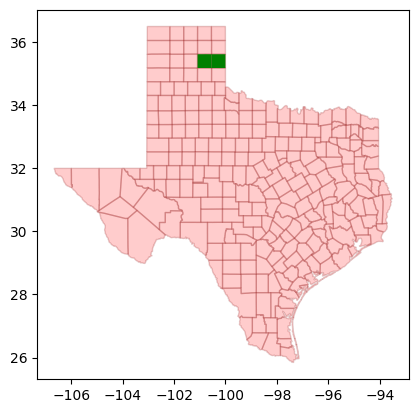

In [10]:
ax = gdf_counties.plot(color='red', edgecolor='maroon', alpha=.2)
gdf_query.plot(ax=ax, color='green')
#gdf_counties.sample(frac=0.1).plot(color='red', edgecolor='maroon', alpha=.2)
plt.show()

In [11]:
# %%time
# remote_directory = remote_directory_pipelines
# gdf_pipelines = geopandas.read_parquet(
#     's3://'+remote_directory,
#     storage_options={
#         'key' : access_key_id,
#         'secret' : secret_access_key,
#         'client_kwargs' : {'endpoint_url': endpoint_url},
#     },
#     # columns=['NAME', 'REGION', 'timestamp', 'geometry'],
#     # filters=[
#     #     ('REGION', '=', 'TX'),
#     #     #('NAME', 'in', ['Gray', 'Wheeler']),
#     # ]
# )
# gdf_pipelines.tail(2)

In [12]:
# #gdf_pipelines.plot(color='red', edgecolor='maroon', alpha=.2)
# gdf_pipelines.sample(frac=0.1).plot(color='red', edgecolor='maroon', alpha=.2)
# plt.show()

# Read COS using DuckDB

In [13]:
def query_remote(remote_path, endpoint_url, access_key_id, secret_access_key, query_polygon):
    s3_endpoint = endpoint_url.split('https://')[1]
    s3_region = 'us-east'

    # Setup
    db = duckdb.connect(":memory:")
    #db.execute("INSTALL aws; LOAD aws;")
    db.execute("INSTALL httpfs; LOAD httpfs;")
    db.execute("INSTALL spatial; LOAD spatial;")

    # Define Connection to Object Storage
    db.execute(f"SET s3_region='{s3_region}'")
    db.execute(f"SET s3_endpoint='{s3_endpoint}'")
    db.execute(f"SET s3_access_key_id='{access_key_id}'")
    db.execute(f"SET s3_secret_access_key='{secret_access_key}'")
    db.execute("SET s3_url_style='path'")
    #db.execute("SET s3_use_ssl=true")

    # Create a table view
    filepath = 's3://' + os.path.join(remote_path, '**/*.parquet').replace('\\', '/')
    db.execute(f"CREATE VIEW tbl AS SELECT * FROM parquet_scan('{filepath}')")
    #cols = [t[0] for t in db.execute("describe tbl").fetchall()]

    # Create a derived table where the geometry column is a true geometry, not just a WKB.
    query = f"""
    CREATE OR REPLACE TABLE tbl2 AS
        SELECT *, ST_GEOMFROMWKB(geometry) as geom
        FROM tbl;
    """
    db.execute(query)
    cols2 = [t[0] for t in db.execute(f"""describe tbl2""").fetchall()]

    # Do the query
    json_string = shapely.to_geojson(query_polygon) # Upstate Ithaca
    query = f"""select * from tbl2 where ST_INTERSECTS(geom, ST_GeomFromGeoJSON('{json_string}'))"""
    gdf = db.execute(query).fetchall()
    gdf = pandas.DataFrame(gdf, columns=cols2)
    gdf['geometry'] = gdf['geometry'].apply(lambda x: wkb.loads(x, hex=True))
    
    return geopandas.GeoDataFrame(gdf)

In [14]:
%%time
gdf_pipelines = query_remote(
    remote_directory_pipelines, endpoint_url, access_key_id, secret_access_key, query_polygon
)
gdf_pipelines['geometry'] = gdf_pipelines.intersection(query_polygon) # Cuts the shapes
gdf_pipelines.tail()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: total: 2.81 s
Wall time: 20.5 s


,OBJECTID,TPMS_ID,OPER_LINK,OPS_ID,P5_NUM,OPER_NM,SYS_NM,SUBSYS_NM,T4PERMIT,DIAMETER,...,LENGTH,Shape__Len,geometry,timestamp,_root,_geom_area,_geom_length,grid,spatial_partition,geom
12377,182707,3230036,0,0,251677,"ENABLE GAS GATHERING, LLC",RANKIN,L-1053,03858,4.5,...,0.0,22.574435,"LINESTRING (-100.01467 35.61908, -100.01465 35...",2022-10-05,0q02133002131202001310,0.0,0.022550,World(4326),0q0213,b'\x01\x04(\x00\x00\x00\x00\x00\x83\x07\xc8\xc...
12378,179983,3416307,0,0,564714,MIDCOAST PL (TX GATHERING) L.P.,TXOK,ANADARKO,06106,4.5,...,0.0,65.295334,"LINESTRING (-100.00356 35.61902, -100.00294 35...",2022-10-05,0q021330021312021,0.0,0.065241,World(4326),0q0213,b'\x01\x04(\x00\x00\x00\x00\x00\xd4\x01\xc8\xc...
12379,447388,3417396,0,0,564714,MIDCOAST PL (TX GATHERING) L.P.,TXOK,ANADARKO,06106,4.5,...,0.0,386.678849,"LINESTRING (-100.00469 35.61822, -100.00103 35...",2022-10-05,0q021330021312021,0.0,0.386384,World(4326),0q0213,b'\x04\x04X\x00\x00\x00\x00\x00h\x02\xc8\xc2\r...
12380,446723,3416306,0,0,564714,MIDCOAST PL (TX GATHERING) L.P.,TXOK,ANADARKO,06106,4.5,...,0.0,223.464946,"LINESTRING (-100.00551 35.61839, -100.00557 35...",2022-10-05,0q02133002131202101,0.0,0.223275,World(4326),0q0213,"b""\x01\x048\x00\x00\x00\x00\x00\xda\x02\xc8\xc..."
12381,446704,3416307,0,0,564714,MIDCOAST PL (TX GATHERING) L.P.,TXOK,ANADARKO,06106,4.5,...,0.0,0.139246,"LINESTRING (-100.00357 35.61902, -100.00356 35...",2022-10-05,0q0213300213120210113232202,0.0,0.000139,World(4326),0q0213,"b""\x01\x04(\x00\x00\x00\x00\x00\xd4\x01\xc8\xc..."


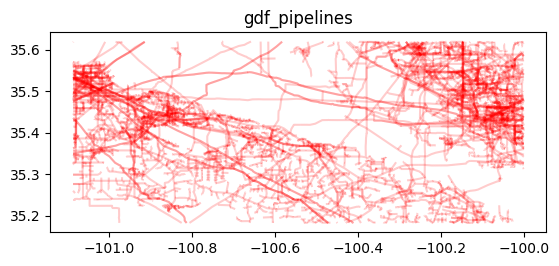

In [19]:
gdf_pipelines.plot(color='red', edgecolor='maroon', alpha=.2)
plt.title('gdf_pipelines')
plt.show()

In [16]:
%%time
gdf_oil_gas = query_remote(
    remote_directory_oil_gas, endpoint_url, access_key_id, secret_access_key, query_polygon
)
gdf_oil_gas['geometry'] = gdf_oil_gas.intersection(query_polygon) # Cuts the shapes
gdf_oil_gas.tail()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: total: 12.2 s
Wall time: 29.2 s


,OGIM_ID,CATEGORY,REGION,COUNTRY,STATE_PROV,SRC_REF_ID,SRC_DATE,ON_OFFSHORE,FAC_NAME,FAC_ID,...,UPDATE_FREQUENCY_SCORE,AGGREGATE_QUALITY_SCORE,geometry,timestamp_completed,_root,_geom_area,_geom_length,grid,spatial_partition,geom
7829,OGIM_2122300,OIL AND NATURAL GAS WELLS,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,"80, 82",1900-01-01,ONSHORE,SHEETS,48333919,...,4,0.8750,POINT (-100.51377 35.37569),2016-12-02 19:00:00-05:00,0q02133002102003322222013031,0.0,0.0,World(4326),0q0213300,b'\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00...
7830,OGIM_2123886,OIL AND NATURAL GAS WELLS,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,"80, 82",1900-01-01,ONSHORE,"BRITT RANCH ""I"" 4",48331689,...,4,0.8125,POINT (-100.05660 35.51974),2017-03-25 20:00:00-04:00,0q02133002130110210120202223,0.0,0.0,World(4326),0q0213300,b'\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00...
7831,OGIM_2124187,OIL AND NATURAL GAS WELLS,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,"80, 82",1900-01-01,ONSHORE,WILLIAMS 33,48331787,...,4,0.8125,POINT (-100.11478 35.58365),2017-05-07 20:00:00-04:00,0q02133002130033123210322102,0.0,0.0,World(4326),0q0213300,"b""\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00..."
7832,OGIM_2123765,OIL AND NATURAL GAS WELLS,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,"80, 82",1900-01-01,ONSHORE,G.C. DAVIS,48332222,...,4,0.8750,POINT (-100.03640 35.40437),2017-06-19 20:00:00-04:00,0q02133002112133021130312311,0.0,0.0,World(4326),0q0213300,b'\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00...
7833,OGIM_1828831,OIL AND NATURAL GAS WELLS,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,"80, 82",1900-01-01,ONSHORE,"TAYLOR, W. H. FEE NCT-A",17903402,...,4,0.8750,POINT (-100.86448 35.36361),2017-10-06 20:00:00-04:00,0q02133002012003122032333230,0.0,0.0,World(4326),0q0213300,b'\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00...


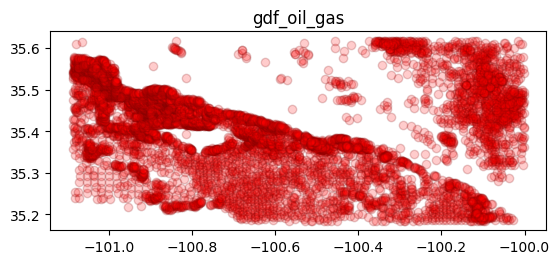

In [20]:
gdf_oil_gas.plot(color='red', edgecolor='maroon', alpha=.2)
plt.title('gdf_oil_gas')
plt.show()

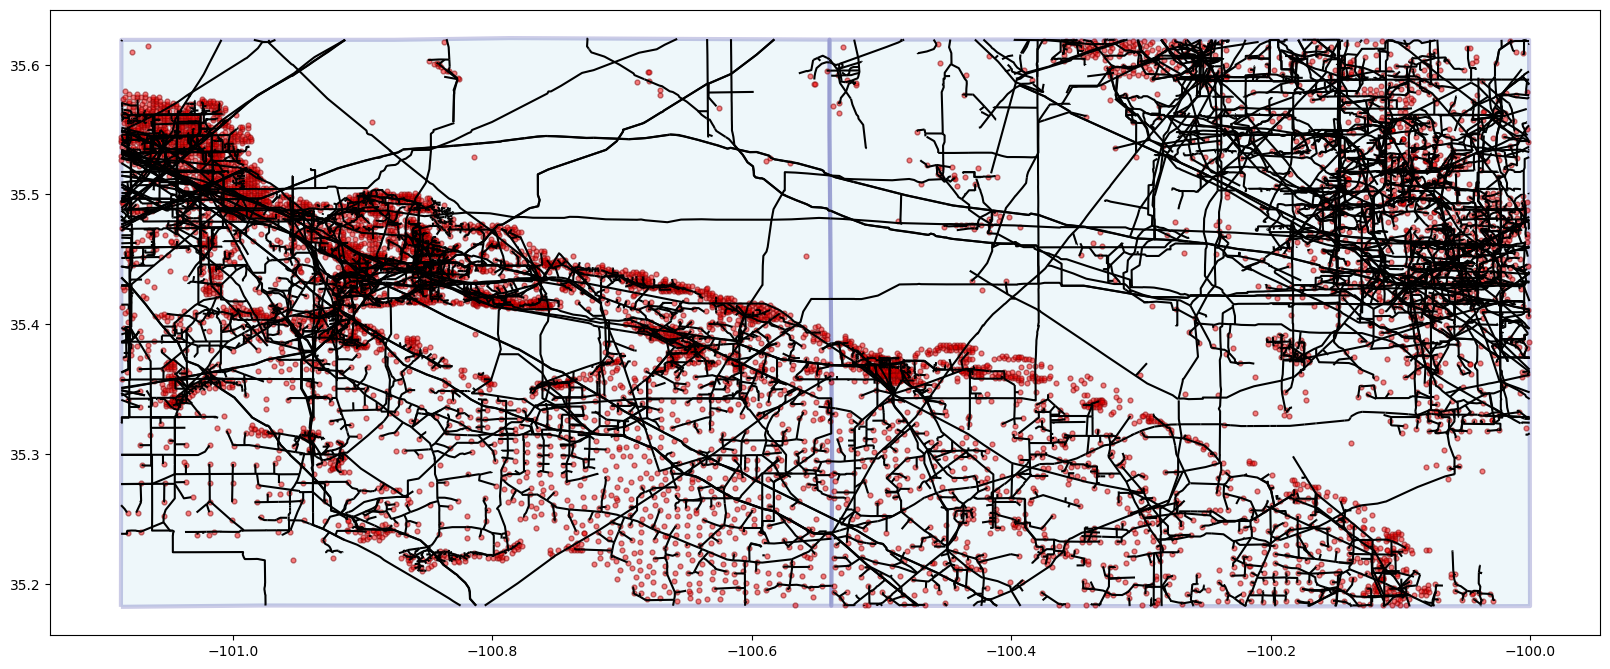

In [18]:
ax = gdf_query.plot(color='lightblue', edgecolor='darkblue', alpha=.2, lw=3, figsize=(20,20))
gdf_pipelines.plot(ax=ax, color='k', edgecolor='k')
gdf_oil_gas.plot(ax=ax, color='red', edgecolor='maroon', alpha=.5, markersize=12)
plt.show()